In [1]:
from pathlib import Path

from caf.base import DVector, ZoningSystem
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from numpy.polynomial.polynomial import polyfit

plt.style.use(r'https://raw.githubusercontent.com/Transport-for-the-North/caf.viz/main/src/caf/viz/tfn.mplstyle')

In [2]:
output_dir = Path(r"I:\NorMITs NorCOM\Reporting\figs")

In [21]:
input_file = Path(r"I:\NorMITs NorCOM\Validation\post-GOR-adjustment\v38\2021\2021_validation_v38.xlsx")
# input_file = Path(r"I:\NorMITs NorCOM\Validation\v38\2021\2021_validation_v38.xlsx")
ref = "-adjusted"
# ref = ""

In [6]:
absolute_data = pd.read_excel(input_file, sheet_name="SUMMARY", header=[0, 1])

In [7]:
absolute_data.head()

LSOA2021 Expected Car Availability                 \
  Unnamed: 0_level_1                         1    2   3 Total   
0          E01000001                       555  243  40   838   
1          E01000002                       578  208  39   825   
2          E01000003                       826  169  22  1017   
3          E01000005                       375   92  12   479   
4          E01000842                       379  274  52   705   

  Resulting Car Availability                                   
                           1          2         3       Total  
0                  382.78477  396.30726  60.90796   839.99999  
1                  385.93629  383.46080  56.60291   826.00000  
2                  523.19209  439.30896  52.49895  1015.00000  
3                  275.33389  174.45443  29.21168   479.00000  
4                  350.29533  300.66295  52.04172   703.00000

In [8]:
dfs = []
r_squareds = []
slopes = []
intercepts = []
for j in range(1, 4):
    # get data to plot
    filtered = absolute_data[[("LSOA2021", "Unnamed: 0_level_1"), ("Expected Car Availability", j), ("Resulting Car Availability", j)]]
    filtered.columns = ["LSOA", "Expected", "Resulting"]

    # calculate line of best fit
    i, s = polyfit(filtered["Expected"], filtered["Resulting"], 1)

    # calculate r2
    r2 = filtered["Expected"].corr(filtered["Resulting"]) ** 2

    # calculate LOBF
    filtered["lobf"] = s * filtered["Expected"] + i

    # store all outputs
    dfs.append(filtered)
    intercepts.append(i)
    slopes.append(s)
    r_squareds.append(r2)

C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_30752\3497938195.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["lobf"] = s * filtered["Expected"] + i
C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_30752\3497938195.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["lobf"] = s * filtered["Expected"] + i
C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_30752\3497938195.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

Text(0, 0.5, 'Predicted Number of Households (Land Use)')

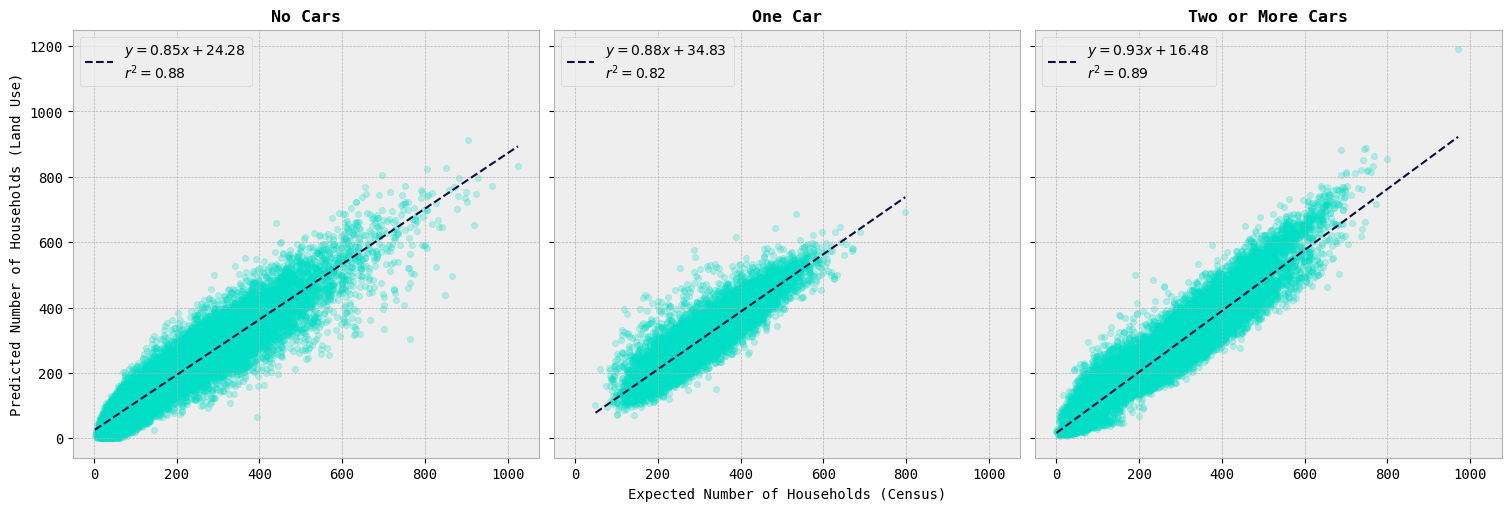

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, figsize=(15, 5))

for ax, data, slope, intercept, rsq in zip(axes, dfs, slopes, intercepts, r_squareds):
    data.plot.scatter(x="Expected", y="Resulting", ax=ax, color="C1", alpha=0.25)
    data.iloc[[data["Expected"].idxmin(), data["Expected"].idxmax()]].plot.line(
        x="Expected", y="lobf", ax=ax, ls="--", color="C0", label=f"$y={slope:.2f}x+{intercept:.2f}$ \n$r^2={rsq:.2f}$"
    )
    ax.legend(loc="upper left")

axes[0].set_title("No Cars", weight="bold")
axes[1].set_title("One Car", weight="bold")
axes[2].set_title("Two or More Cars", weight="bold")

axes[0].set_xlabel("")
axes[2].set_xlabel("")
axes[1].set_xlabel("Expected Number of Households (Census)")
axes[0].set_ylabel("Predicted Number of Households (Land Use)")

In [10]:
fig.savefig(output_dir / f"v38_households_2021{ref}.png")
plt.close()

In [11]:
for tab in ["MODEL SHARES", "NORTHERN SHARES"]:
    share_data = pd.read_excel(input_file, sheet_name=tab, header=[0, 1])

    dfs = []
    r_squareds = []
    slopes = []
    intercepts = []
    for col in ["No Cars", "1+ Cars", "1 Car", "2+ Cars"]:
        # get data to plot
        filtered = share_data[[("LSOA2021", "Unnamed: 0_level_1"), ("Expected Car Availability", col), ("Resulting Car Availability", col)]]
        filtered.columns = ["LSOA", "Expected", "Resulting"]
    
        # calculate line of best fit
        i, s = polyfit(filtered["Expected"], filtered["Resulting"], 1)
    
        # calculate r2
        r2 = filtered["Expected"].corr(filtered["Resulting"]) ** 2
    
        # calculate LOBF
        filtered["lobf"] = s * filtered["Expected"] + i
    
        # store all outputs
        dfs.append(filtered)
        intercepts.append(i)
        slopes.append(s)
        r_squareds.append(r2)

    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(10, 10))

    for ax, data, slope, intercept, rsq in zip(axes.ravel(), dfs, slopes, intercepts, r_squareds):
        data.plot.scatter(x="Expected", y="Resulting", ax=ax, color="C1", alpha=0.25)
        data.iloc[[data["Expected"].idxmin(), data["Expected"].idxmax()]].plot.line(
            x="Expected", y="lobf", ax=ax, ls="--", color="C0", label=f"$y={slope:.2f}x+{intercept:.2f}$ \n$r^2={rsq:.2f}$"
        )
        ax.legend(loc="upper left")
    
    axes[(0, 0)].set_title("No Cars", weight="bold")
    axes[(0, 1)].set_title("One or More Cars", weight="bold")
    axes[(1, 0)].set_title("One Car", weight="bold")
    axes[(1, 1)].set_title("Two or More Cars", weight="bold")
    
    axes[(0, 0)].yaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
    )
    axes[(0, 0)].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
    axes[(0, 0)].xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
    )
    axes[(0, 0)].xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
    
    axes[(0, 0)].set_xlim([0, 1])
    axes[(0, 0)].set_ylim([0, 1])
    
    fig.suptitle("Proportion of Households", weight="bold")

    fig.savefig(output_dir / f"v38_shares_2021-{''.join(tab.split(' '))}{ref}.png")
    plt.close()

C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_30752\4246540913.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["lobf"] = s * filtered["Expected"] + i
C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_30752\4246540913.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["lobf"] = s * filtered["Expected"] + i
C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_30752\4246540913.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [22]:
share_data = pd.read_excel(input_file, sheet_name="NORTHERN SHARES", header=[0, 1])
share_data.head()

LSOA2021 Expected Car Availability                      \
  Unnamed: 0_level_1                         1         2         3   
0          E01004766                  0.345342  0.397516  0.257143   
1          E01004767                  0.269545  0.478413  0.252042   
2          E01004768                  0.057003  0.294788  0.648208   
3          E01004769                  0.107195  0.472834  0.419971   
4          E01004770                  0.114566  0.458265  0.427169   

  Resulting Car Availability                          \
                           1         2         3 3.1   
0                   0.365533  0.434316  0.200150 NaN   
1                   0.347246  0.423691  0.229063 NaN   
2                   0.072116  0.335533  0.592352 NaN   
3                   0.198267  0.450035  0.351698 NaN   
4                   0.176396  0.433206  0.390399 NaN   

  Expected Car Availability            ... Resulting Car Availability  \
                    No Cars   1+ Cars  ...                 2+ Cars.18   
0                  0.345342  0.654658  ...                        NaN   
1                  0.269545  0.730455  ...                        NaN   
2                  0.057003  0.942997  ...                        NaN   
3                  0.107195  0.892805  ...                        NaN   
4                  0.114566  0.885434  ...                        NaN   

  Difference                                                              \
     No Cars   1+ Cars     1 Car   2+ Cars 2+ Cars.1 2+ Cars.2 2+ Cars.3   
0   0.020192 -0.020192  0.077327 -0.077327       NaN       NaN       NaN   
1   0.077701 -0.077701 -0.005869  0.005869       NaN       NaN       NaN   
2   0.015112 -0.015112  0.049002 -0.049002       NaN       NaN       NaN   
3   0.091072 -0.091072  0.031722 -0.031722       NaN       NaN       NaN   
4   0.061829 -0.061829  0.008427 -0.008427       NaN       NaN       NaN   

                       
  2+ Cars.4 2+ Cars.5  
0       NaN       NaN  
1       NaN       NaN  
2       NaN       NaN  
3       NaN       NaN  
4       NaN       NaN  

[5 rows x 43 columns]

In [23]:
filtered = share_data[[("LSOA2021", "Unnamed: 0_level_1"), ("Difference", "No Cars"), ("Difference", "1+ Cars"), ("Difference", "1 Car"), ("Difference", "2+ Cars")]]
filtered.columns = ["LSOA", "No Cars", "1+ Cars", "1 Car", "2+ Cars"]

Text(0.5, 0, 'pp Change from Census')

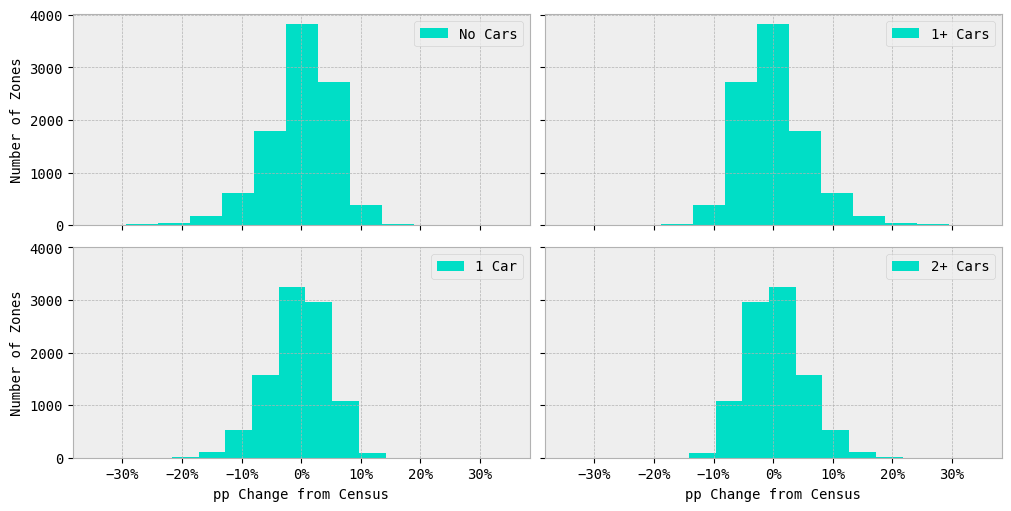

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(10, 5))
cols = ["No Cars", "1+ Cars", "1 Car", "2+ Cars"]

for ax, col in zip(axes.ravel(), cols):
    filtered.plot.hist(column=[col], ax=ax, color="C1", bins=10, )

axes[(0, 0)].xaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
)
axes[(0, 0)].xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
axes[(0, 0)].set_ylabel("Number of Zones")
axes[(1, 0)].set_ylabel("Number of Zones")
axes[(1, 0)].set_xlabel("pp Change from Census")
axes[(1, 1)].set_xlabel("pp Change from Census")

In [25]:
fig.savefig(output_dir / f"v38_shares_summary_2021{ref}.png")
plt.close()